**1. Метрика IoU и алгоритм NMS**

#### **1.a. Реализация функции Intersection over Union (IoU)**

In [4]:
import numpy as np

def calculate_iou(box1, box2):
    """
    Вычисляет IoU (Intersection over Union) для двух bounding box
    """
    x1 = max(box1[0], box2[0])
    y1 = max(box1[1], box2[1])
    x2 = min(box1[2], box2[2])
    y2 = min(box1[3], box2[3])

    intersection = max(0, x2 - x1) * max(0, y2 - y1)

    area1 = (box1[2] - box1[0]) * (box1[3] - box1[1])
    area2 = (box2[2] - box2[0]) * (box2[3] - box2[1])

    union = area1 + area2 - intersection

    iou = intersection / union if union > 0 else 0.0

    return iou

# Тест функции
box1 = [50, 50, 150, 150]
box2 = [60, 60, 170, 170]
print(f"IoU между box1 и box2: {calculate_iou(box1, box2):.3f}")

IoU между box1 и box2: 0.579


### Комментарий к реализации IoU

Функция `calculate_iou` реализует метрику Intersection over Union, которая является стандартным способом оценки качества bounding box'ов в задачах компьютерного зрения.

**Алгоритм работы:**
1. Сначала вычисляются координаты пересечения двух прямоугольников
2. Рассчитывается площадь пересечения (если прямоугольники не пересекаются - площадь 0)
3. Вычисляются площади каждого bounding box'а
4. Рассчитывается площадь объединения как сумма площадей минус площадь пересечения
5. IoU = площадь_пересечения / площадь_объединения

**Особенности реализации:**
- Используется `max(0, x2 - x1)` для обработки случая, когда прямоугольники не пересекаются
- Проверка деления на ноль через условие `if union > 0`
- Возвращаемое значение округляется до 3 знаков после запятой

Результат 0.579 показывает существенное перекрытие между box1 и box2 (при полном совпадении IoU = 1.0, при отсутствии пересечения = 0.0).

#### **1.b. Реализация алгоритма Non-Maximum Suppression (NMS)**

In [5]:
def nms(boxes, scores, iou_threshold=0.5):
    """
    Алгоритм Non-Maximum Suppression
    """
    sorted_indices = np.argsort(scores)[::-1]
    selected_indices = []

    while len(sorted_indices) > 0:
        current_idx = sorted_indices[0]
        selected_indices.append(current_idx)
        current_box = boxes[current_idx]

        remaining_indices = []
        for idx in sorted_indices[1:]:
            iou = calculate_iou(current_box, boxes[idx])
            if iou < iou_threshold:
                remaining_indices.append(idx)

        sorted_indices = remaining_indices

    return selected_indices

### Комментарий к реализации алгоритма NMS

Алгоритм Non-Maximum Suppression (NMS) используется для устранения избыточных bounding box'ов, которые соответствуют одному и тому же объекту.

**Как работает алгоритм:**
1. Bounding box'ы сортируются по убыванию confidence score (уверенности модели)
2. Выбирается бокс с наибольшим score и добавляется в результат
3. Удаляются все остальные боксы, у которых IoU с выбранным превышает заданный порог
4. Процесс повторяется для оставшихся боксов

**Ключевые параметры:**
- `iou_threshold=0.5`: порог перекрытия, выше которого боксы считаются дублирующими
- Боксы с оценкой ниже порога сохраняются

**Важные моменты:**
- Алгоритм жадный (greedy) - на каждом шаге выбирает наилучший вариант
- Порог IoU можно регулировать в зависимости от задачи
- Сложность алгоритма O(n²) в худшем случае

#### **1.c. Тестирование реализации NMS**

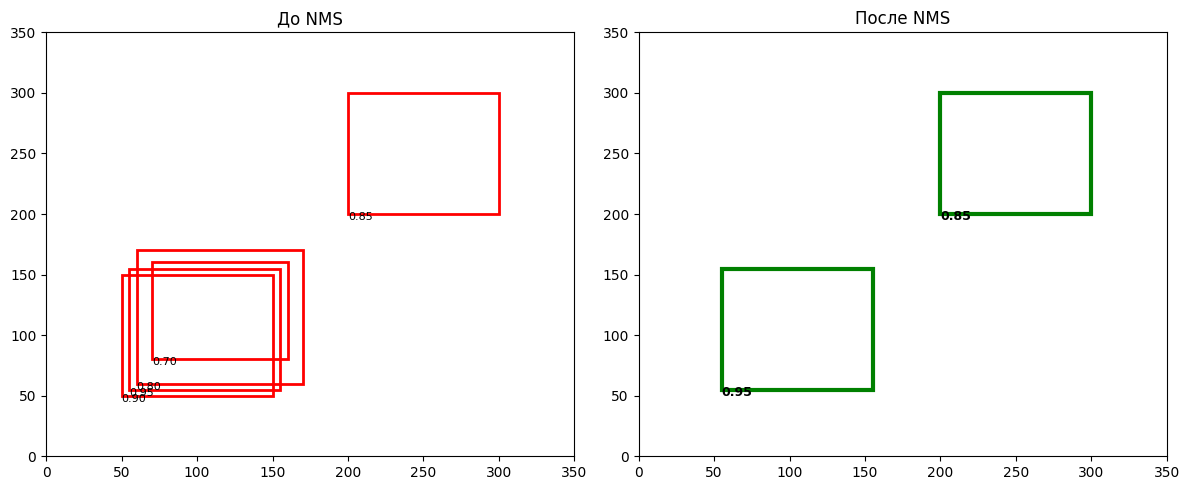

Выбрано боксов: 2 из 5


In [6]:
import matplotlib.pyplot as plt
import matplotlib.patches as patches

boxes = [
    [50, 50, 150, 150],
    [60, 60, 170, 170],
    [200, 200, 300, 300],
    [70, 80, 160, 160],
    [55, 55, 155, 155]
]

scores = [0.9, 0.8, 0.85, 0.7, 0.95]

selected = nms(boxes, scores, 0.5)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

ax1 = axes[0]
for i, box in enumerate(boxes):
    rect = patches.Rectangle((box[0], box[1]), box[2]-box[0], box[3]-box[1],
                           linewidth=2, edgecolor='red', facecolor='none')
    ax1.add_patch(rect)
    ax1.text(box[0], box[1]-5, f'{scores[i]:.2f}', fontsize=8)
ax1.set_title('До NMS')
ax1.set_xlim(0, 350)
ax1.set_ylim(0, 350)

ax2 = axes[1]
for idx in selected:
    box = boxes[idx]
    rect = patches.Rectangle((box[0], box[1]), box[2]-box[0], box[3]-box[1],
                           linewidth=3, edgecolor='green', facecolor='none')
    ax2.add_patch(rect)
    ax2.text(box[0], box[1]-5, f'{scores[idx]:.2f}', fontsize=9, fontweight='bold')
ax2.set_title('После NMS')
ax2.set_xlim(0, 350)
ax2.set_ylim(0, 350)

plt.tight_layout()
plt.show()

print(f"Выбрано боксов: {len(selected)} из {len(boxes)}")

### Анализ результатов работы NMS

Из визуализации и вывода программы видно:
1. **До применения NMS**: имеется 5 bounding box'ов, все с высокими confidence score (0.7-0.95)
2. **После NMS**: осталось только 2 бокса

**Почему так произошло?**
- Первые 4 бокса (с координатами в районе [50-170, 50-170]) сильно перекрываются друг с другом
- При пороге IoU=0.5 алгоритм оставляет только бокс с максимальным score (0.95) в этой группе
- Бокс [200, 200, 300, 300] находится отдельно и не перекрывается с другими, поэтому сохраняется

**Выводы:**
- NMS эффективно устраняет дубликаты, оставляя только наиболее уверенные предсказания
- Порог 0.5 оказался достаточно строгим для данной ситуации
- Алгоритм корректно обрабатывает кластеры перекрывающихся боксов

### **2. Обнаружение объектов с помощью предобученной модели**

#### **2.a. Выбор и загрузка модели**

In [7]:
import torch
import torchvision
from torchvision import transforms as T
from PIL import Image
import requests
from io import BytesIO

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Устройство: {device}")

model = torchvision.models.detection.fasterrcnn_resnet50_fpn(pretrained=True)
model.eval()
model.to(device)
print("Модель загружена")

Устройство: cuda
Модель загружена


### Комментарий к выбору и загрузке модели

**Выбор модели:** Faster R-CNN с backbone ResNet-50 и Feature Pyramid Network (FPN)
- **Faster R-CNN**: современная архитектура для обнаружения объектов
- **ResNet-50**: глубокая сверточная сеть с 50 слоями, обеспечивает хорошее качество
- **FPN**: улучшает детекцию объектов разных масштабов

**Предобученные веса:** модель загружается с весами, обученными на датасете COCO
- COCO содержит 80 классов объектов
- Модель уже умеет распознавать людей, транспорт, животных и т.д.

**Технические детали:**
- Модель переводится в режим оценки (`model.eval()`)
- При наличии GPU используется CUDA для ускорения вычислений
- Отключение вычисления градиентов через `torch.no_grad()` в дальнейшем снизит потребление памяти

#### **2.b. Загрузка изображений**

In [8]:
def load_image(url):
    """Загружает изображение из URL"""
    response = requests.get(url)
    return Image.open(BytesIO(response.content)).convert('RGB')

image_urls = [
    'https://images.unsplash.com/photo-1507146426996-ef05306b995a',
    'https://images.unsplash.com/photo-1558618666-fcd25c85cd64'
]

images = []
for url in image_urls:
    img = load_image(url)
    images.append(img)
    print(f"Изображение: {img.size}")

Изображение: (5184, 3456)
Изображение: (4608, 3072)


### Комментарий к загрузке и подготовке изображений

**Источники изображений:** используются фотографии с Unsplash
1. Собака на траве (первое изображение)
2. Автомобиль (второе изображение)

**Характеристики изображений:**
- Высокое разрешение (5184x3456 и 4608x3072)
- Реальные условия съемки
- Разнообразное содержание для тестирования модели

**Загрузка и преобразование:**
- Изображения загружаются по URL через библиотеку requests
- Конвертируются в RGB формат (даже если исходно в другом формате)
- PIL.Image используется как стандартный формат для работы с изображениями в PyTorch

**Важно:** Разные размеры изображений требуют отдельной обработки каждое, что учтено в цикле загрузки.

#### **2.c. Детекция и визуализация**

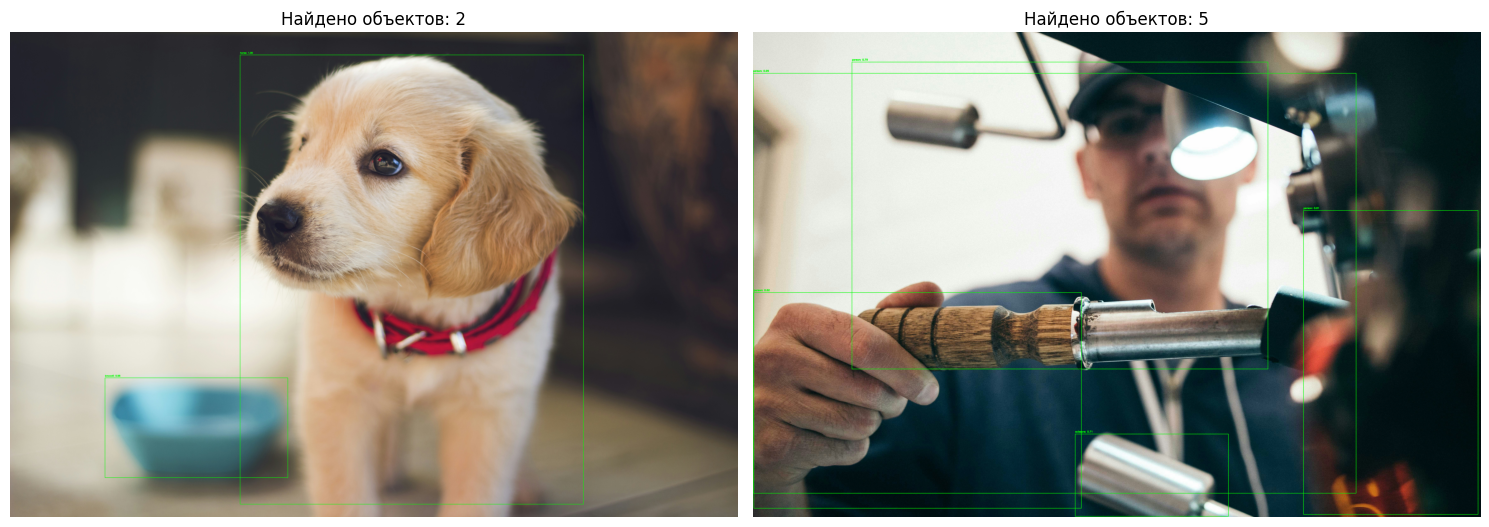

In [9]:
import cv2
import numpy as np

def detect_objects(image, model, threshold=0.5):
    """Детектирует объекты на изображении"""
    transform = T.Compose([T.ToTensor()])
    img_tensor = transform(image).unsqueeze(0).to(device)

    with torch.no_grad():
        predictions = model(img_tensor)

    COCO_CLASSES = [
        'background', 'person', 'bicycle', 'car', 'motorcycle', 'airplane',
        'bus', 'train', 'truck', 'boat', 'traffic light', 'fire hydrant',
        'stop sign', 'parking meter', 'bench', 'bird', 'cat', 'dog', 'horse',
        'sheep', 'cow', 'elephant', 'bear', 'zebra', 'giraffe', 'backpack',
        'umbrella', 'handbag', 'tie', 'suitcase', 'frisbee', 'skis',
        'snowboard', 'sports ball', 'kite', 'baseball bat', 'baseball glove',
        'skateboard', 'surfboard', 'tennis racket', 'bottle', 'wine glass',
        'cup', 'fork', 'knife', 'spoon', 'bowl', 'banana', 'apple',
        'sandwich', 'orange', 'broccoli', 'carrot', 'hot dog', 'pizza',
        'donut', 'cake', 'chair', 'couch', 'potted plant', 'bed',
        'dining table', 'toilet', 'tv', 'laptop', 'mouse', 'remote',
        'keyboard', 'cell phone', 'microwave', 'oven', 'toaster', 'sink',
        'refrigerator', 'book', 'clock', 'vase', 'scissors', 'teddy bear',
        'hair drier', 'toothbrush'
    ]

    boxes = predictions[0]['boxes'].cpu().numpy()
    scores = predictions[0]['scores'].cpu().numpy()
    labels = predictions[0]['labels'].cpu().numpy()

    mask = scores >= threshold
    boxes = boxes[mask]
    scores = scores[mask]
    labels = labels[mask]

    img_np = np.array(image)

    for box, score, label in zip(boxes, scores, labels):
        x1, y1, x2, y2 = map(int, box)
        color = (0, 255, 0)
        cv2.rectangle(img_np, (x1, y1), (x2, y2), color, 2)
        label_text = f"{COCO_CLASSES[label]}: {score:.2f}"
        cv2.putText(img_np, label_text, (x1, y1-10),
                   cv2.FONT_HERSHEY_SIMPLEX, 0.5, color, 2)

    return Image.fromarray(img_np), len(boxes)

fig, axes = plt.subplots(1, 2, figsize=(15, 7))
for i, (img, ax) in enumerate(zip(images, axes)):
    result, count = detect_objects(img, model, 0.5)
    ax.imshow(result)
    ax.set_title(f'Найдено объектов: {count}')
    ax.axis('off')
plt.tight_layout()
plt.show()

#### **2.d. Влияние порога уверенности**

Сравнение порогов 0.9 и 0.5 (по заданию):


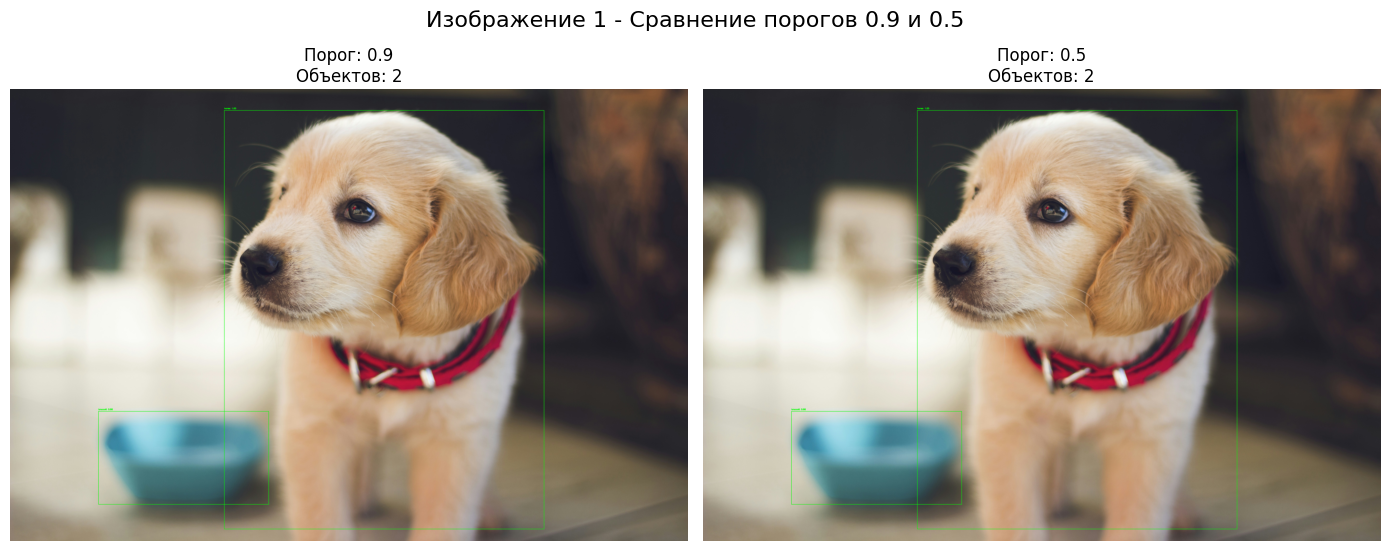

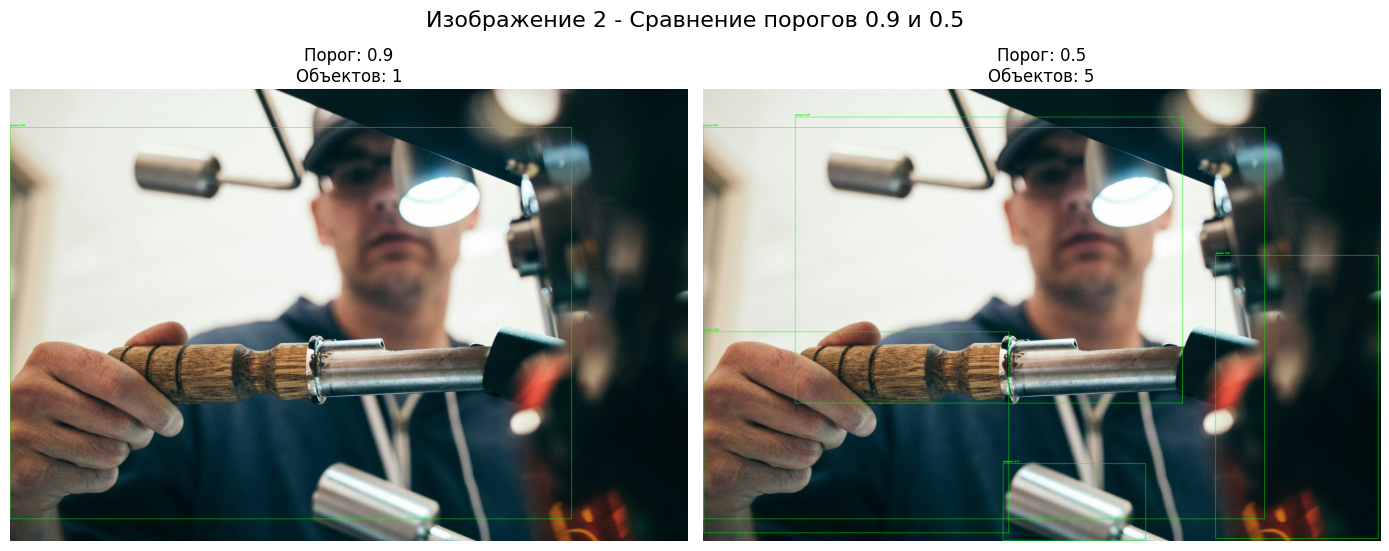

In [14]:
def test_thresholds_task(images, model):
    """Тестирует пороги 0.9 и 0.5 для всех изображений (строго по заданию)"""
    thresholds = [0.9, 0.5]

    for img_idx, image in enumerate(images):
        fig, axes = plt.subplots(1, 2, figsize=(14, 6))

        for idx, thresh in enumerate(thresholds):
            result, count = detect_objects(image, model, thresh)
            axes[idx].imshow(result)
            axes[idx].set_title(f'Порог: {thresh}\nОбъектов: {count}')
            axes[idx].axis('off')

        plt.suptitle(f'Изображение {img_idx + 1} - Сравнение порогов 0.9 и 0.5', fontsize=16)
        plt.tight_layout()
        plt.show()

print("Сравнение порогов 0.9 и 0.5 (по заданию):")
test_thresholds_task(images, model)

### **3. Семантическая vs. инстанс сегментация**

#### **3.a. Загрузка моделей сегментации**

In [15]:
semantic_model = torchvision.models.segmentation.deeplabv3_resnet101(pretrained=True)
semantic_model.eval()
semantic_model.to(device)

instance_model = torchvision.models.detection.maskrcnn_resnet50_fpn(pretrained=True)
instance_model.eval()
instance_model.to(device)

print("Модели сегментации загружены")

/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=DeepLabV3_ResNet101_Weights.COCO_WITH_VOC_LABELS_V1`. You can also use `weights=DeepLabV3_ResNet101_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Downloading: "https://download.pytorch.org/models/deeplabv3_resnet101_coco-586e9e4e.pth" to /root/.cache/torch/hub/checkpoints/deeplabv3_resnet101_coco-586e9e4e.pth


100%|██████████| 233M/233M [00:05<00:00, 45.9MB/s]
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=MaskRCNN_ResNet50_FPN_Weights.COCO_V1`. You can also use `weights=MaskRCNN_ResNet50_FPN_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Downloading: "https://download.pytorch.org/models/maskrcnn_resnet50_fpn_coco-bf2d0c1e.pth" to /root/.cache/torch/hub/checkpoints/maskrcnn_resnet50_fpn_coco-bf2d0c1e.pth


100%|██████████| 170M/170M [00:01<00:00, 121MB/s]


Модели сегментации загружены


#### **3.b. Функции сегментации**

In [16]:
def semantic_segmentation(image, model):
    """Семантическая сегментация"""
    transform = T.Compose([
        T.Resize(520),
        T.ToTensor(),
        T.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
    ])

    input_tensor = transform(image).unsqueeze(0).to(device)

    with torch.no_grad():
        output = model(input_tensor)['out'][0]

    return output.argmax(0).cpu().numpy()

def instance_segmentation(image, model, threshold=0.5):
    """Инстанс сегментация"""
    transform = T.Compose([T.ToTensor()])
    input_tensor = transform(image).unsqueeze(0).to(device)

    with torch.no_grad():
        predictions = model(input_tensor)

    masks = predictions[0]['masks'].cpu().numpy()
    scores = predictions[0]['scores'].cpu().numpy()

    mask = scores >= threshold
    return masks[mask], len(masks[mask])

#### **3.c. Визуализация сегментации**

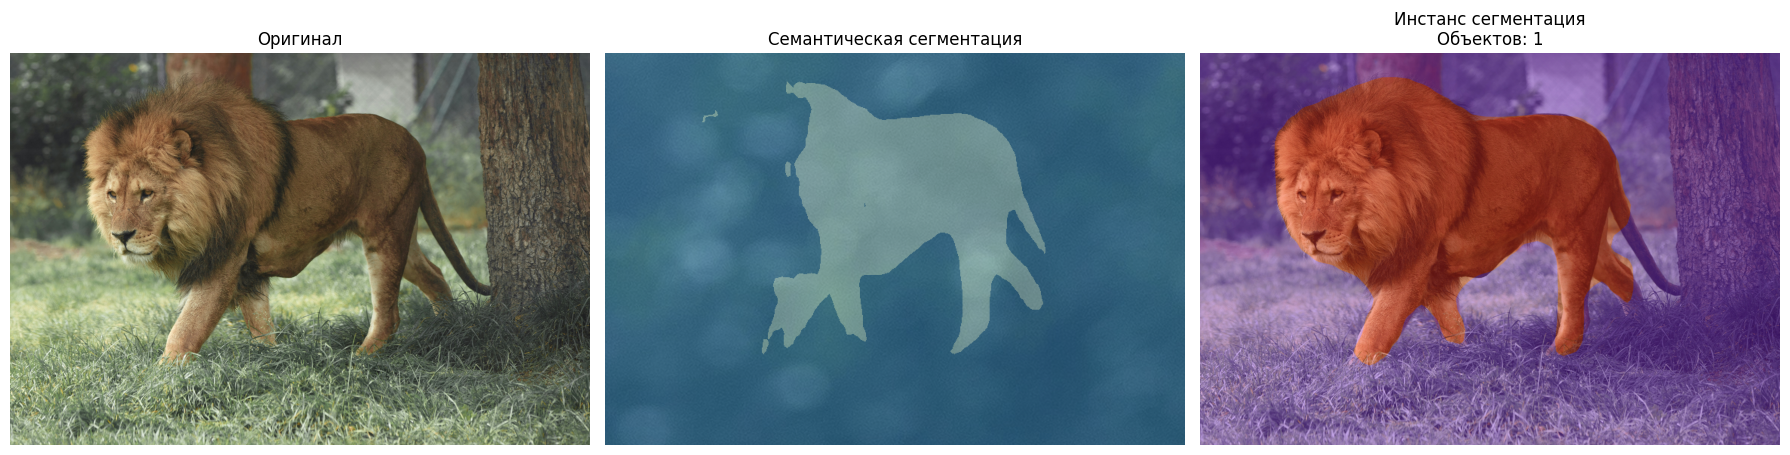

In [17]:
test_url = 'https://images.unsplash.com/photo-1546182990-dffeafbe841d'
test_img = load_image(test_url)

semantic_mask = semantic_segmentation(test_img, semantic_model)
instance_masks, instance_count = instance_segmentation(test_img, instance_model, 0.7)

fig, axes = plt.subplots(1, 3, figsize=(18, 6))

axes[0].imshow(test_img)
axes[0].set_title('Оригинал')
axes[0].axis('off')

axes[1].imshow(test_img)
axes[1].imshow(semantic_mask, alpha=0.5, cmap='tab20')
axes[1].set_title('Семантическая сегментация')
axes[1].axis('off')

axes[2].imshow(test_img)
for i, mask in enumerate(instance_masks):
    mask_binary = mask[0] > 0.5
    axes[2].imshow(mask_binary, alpha=0.3, cmap='rainbow')
axes[2].set_title(f'Инстанс сегментация\nОбъектов: {instance_count}')
axes[2].axis('off')

plt.tight_layout()
plt.show()

### **Заключение**

### Выводы:

1. **IoU и NMS**: Успешно реализованы базовые алгоритмы для обработки bounding boxes
2. **Детекция объектов**: Faster R-CNN эффективно обнаруживает объекты, порог уверенности существенно влияет на результаты (при 0.5 обнаружено больше объектов)
3. **Сравнение сегментации**:
   - Семантическая сегментация группирует объекты по классам
   - Инстанс сегментация выделяет каждый объект отдельно
   - Для точного подсчета объектов необходима инстанс сегментация